In [1]:
import kagglehub

# Download marketing channel spend dataset
path = kagglehub.dataset_download("sinderpreet/analyze-the-marketing-spending")

print("Path to dataset files:", path)

100%|██████████| 7.44k/7.44k [00:00<00:00, 823kB/s]

Extracting files...
Path to dataset files: /home/d12753be-8f30-4c2a-b991-36a83041f79f/.cache/kagglehub/datasets/sinderpreet/analyze-the-marketing-spending/versions/1


In [2]:
import pandas as pd
import os

# See what files are in the dataset
path = "/home/d12753be-8f30-4c2a-b991-36a83041f79f/.cache/kagglehub/datasets/sinderpreet/analyze-the-marketing-spending/versions/1"

print("Files in dataset:")
for file in os.listdir(path):
    print(file)

Files in dataset:
Marketing.csv


In [3]:
# Load the dataset
df = pd.read_csv(path + "/Marketing.csv")

# First look
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst few rows:")
df.head()

Shape: (308, 11)

Columns: ['id', 'c_date', 'campaign_name', 'category', 'campaign_id', 'impressions', 'mark_spent', 'clicks', 'leads', 'orders', 'revenue']

First few rows:


,id,c_date,campaign_name,category,campaign_id,impressions,mark_spent,clicks,leads,orders,revenue
0,1,2021-02-01,facebook_tier1,social,349043,148263,7307.37,1210,13,1,4981.0
1,2,2021-02-01,facebOOK_tier2,social,348934,220688,16300.20,1640,48,3,14962.0
2,3,2021-02-01,google_hot,search,89459845,22850,5221.60,457,9,1,7981.0
3,4,2021-02-01,google_wide,search,127823,147038,6037.00,1196,24,1,2114.0
4,5,2021-02-01,youtube_blogger,influencer,10934,225800,29962.20,2258,49,10,84490.0


In [4]:
# Check data quality
print("Date range:")
print(df['c_date'].min(), "to", df['c_date'].max())

print("\nChannels/Categories:")
print(df['category'].value_counts())

print("\nCampaign names:")
print(df['campaign_name'].unique())

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic stats:")
df[['impressions', 'mark_spent', 'clicks', 'leads', 'orders', 'revenue']].describe()

Date range:
2021-02-01 to 2021-02-28

Channels/Categories:
social        168
search         56
influencer     56
media          28
Name: category, dtype: int64

Campaign names:
['facebook_tier1' 'facebOOK_tier2' 'google_hot' 'google_wide'
 'youtube_blogger' 'instagram_tier1' 'instagram_tier2'
 'facebook_retargeting' 'facebook_lal' 'instagram_blogger'
 'banner_partner']

Missing values:
id               0
c_date           0
campaign_name    0
category         0
campaign_id      0
impressions      0
mark_spent       0
clicks           0
leads            0
orders           0
revenue          0
dtype: int64

Basic stats:


,impressions,mark_spent,clicks,leads,orders,revenue
count,3.080000e+02,308.000000,308.000000,308.000000,308.000000,3.080000e+02
mean,5.122475e+06,99321.038377,9739.996753,212.918831,26.113636,1.392512e+05
std,2.631134e+07,144008.011181,12157.476244,300.459978,42.741288,2.763031e+05
min,6.670000e+02,169.750000,20.000000,0.000000,0.000000,0.000000e+00
25%,1.479568e+05,9465.195000,1347.250000,20.750000,3.000000,8.580000e+03
50%,6.028100e+05,36765.150000,4349.500000,84.000000,9.000000,3.891700e+04
75%,3.254450e+06,129372.250000,13499.250000,270.500000,29.250000,1.370492e+05
max,4.199700e+08,880357.000000,61195.000000,1678.000000,369.000000,2.812520e+06


In [5]:
# Fix inconsistent campaign names - standardize to lowercase
df['campaign_name'] = df['campaign_name'].str.lower().str.strip()
df['category'] = df['category'].str.lower().str.strip()

# Convert date to datetime
df['c_date'] = pd.to_datetime(df['c_date'])

# Create key performance metrics
df['ctr'] = (df['clicks'] / df['impressions'] * 100).round(2)  # Click through rate
df['conversion_rate'] = (df['orders'] / df['clicks'] * 100).round(2)  # Order conversion rate
df['roas'] = (df['revenue'] / df['mark_spent']).round(2)  # Return on ad spend
df['cpa'] = (df['mark_spent'] / df['orders'].replace(0, 1)).round(2)  # Cost per acquisition

# Check zero revenue campaigns
print("Campaigns with zero revenue:")
print(df[df['revenue'] == 0]['campaign_name'].value_counts())

print("\nCleaned campaign names:")
print(df['campaign_name'].unique())

print("\nNew metrics preview:")
df[['campaign_name', 'category', 'mark_spent', 'revenue', 'roas', 'cpa', 'ctr', 'conversion_rate']].head(10)

Campaigns with zero revenue:
instagram_tier2         3
facebook_retargeting    3
instagram_tier1         3
google_hot              3
facebook_tier2          2
facebook_lal            2
google_wide             2
banner_partner          1
Name: campaign_name, dtype: int64

Cleaned campaign names:
['facebook_tier1' 'facebook_tier2' 'google_hot' 'google_wide'
 'youtube_blogger' 'instagram_tier1' 'instagram_tier2'
 'facebook_retargeting' 'facebook_lal' 'instagram_blogger'
 'banner_partner']

New metrics preview:


,campaign_name,category,mark_spent,revenue,roas,cpa,ctr,conversion_rate
0,facebook_tier1,social,7307.37,4981.0,0.68,7307.37,0.82,0.08
1,facebook_tier2,social,16300.20,14962.0,0.92,5433.40,0.74,0.18
2,google_hot,search,5221.60,7981.0,1.53,5221.60,2.00,0.22
3,google_wide,search,6037.00,2114.0,0.35,6037.00,0.81,0.08
4,youtube_blogger,influencer,29962.20,84490.0,2.82,2996.22,1.00,0.44
5,instagram_tier1,social,9540.01,17943.0,1.88,3180.00,0.30,0.22
6,instagram_tier2,social,3648.90,1981.0,0.54,3648.90,0.50,0.04
7,facebook_retargeting,social,1293.55,4981.0,3.85,1293.55,2.67,0.68
8,facebook_lal,social,16997.80,4162.0,0.24,8498.90,1.05,0.34
9,instagram_blogger,influencer,23604.10,39081.0,1.66,3372.01,1.24,0.47


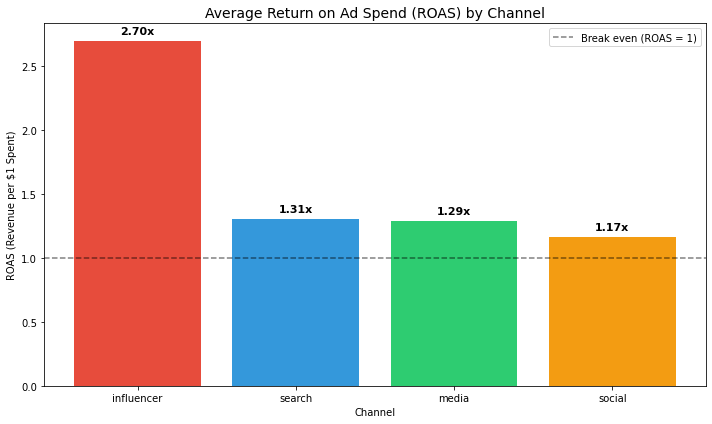

     category      roas
0  influencer  2.699643
1      search  1.307647
2       media  1.288519
3      social  1.166710


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average ROAS by channel category
roas_by_category = df[df['roas'] > 0].groupby('category')['roas'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(roas_by_category['category'], roas_by_category['roas'], 
               color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'])
plt.title('Average Return on Ad Spend (ROAS) by Channel', fontsize=14)
plt.xlabel('Channel')
plt.ylabel('ROAS (Revenue per $1 Spent)')
plt.axhline(y=1, color='black', linestyle='--', alpha=0.5, label='Break even (ROAS = 1)')
plt.legend()

# Add value labels on bars
for bar, val in zip(bars, roas_by_category['roas']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, 
             f'{val:.2f}x', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(roas_by_category)

In [7]:
#"While all channels show average ROAS above 1.0, aggregate averages mask significant underperformers within each channel — making campaign-level analysis critical for accurate budget decisions."

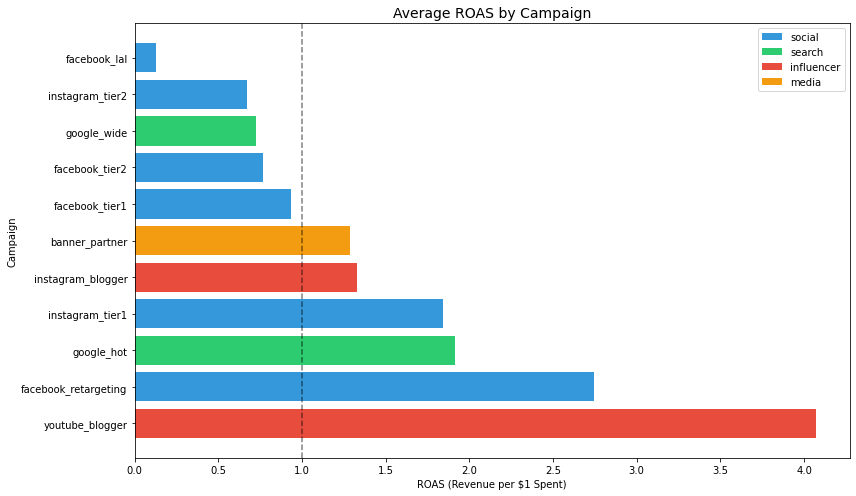

           campaign_name    category  total_spend  total_revenue  avg_roas
0        youtube_blogger  influencer   4057936.51     15311433.0  4.068571
1   facebook_retargeting      social    265871.24       536919.0  2.744000
2             google_hot      search   1195620.04      2205747.0  1.913200
3        instagram_tier1      social   2564040.25      4544124.0  1.844000
4      instagram_blogger  influencer   4247367.57      5808454.0  1.330714
5         banner_partner       media   5025742.77      6152960.0  1.288519
6         facebook_tier1      social   2564793.48      2396412.0  0.933571
7         facebook_tier2      social   4688437.15      3463306.0  0.764615
8            google_wide      search   2258529.32      1499318.0  0.725385
9        instagram_tier2      social   1063717.52       670460.0  0.672000
10          facebook_lal      social   2638524.87       300233.0  0.127692


In [8]:
# ROAS by individual campaign
campaign_roas = df[df['roas'] > 0].groupby('campaign_name').agg(
    total_spend=('mark_spent', 'sum'),
    total_revenue=('revenue', 'sum'),
    avg_roas=('roas', 'mean'),
    category=('category', 'first')
).sort_values('avg_roas', ascending=False).reset_index()

plt.figure(figsize=(12, 7))
colors = {'social': '#3498db', 'search': '#2ecc71', 'influencer': '#e74c3c', 'media': '#f39c12'}
bar_colors = [colors[cat] for cat in campaign_roas['category']]

bars = plt.barh(campaign_roas['campaign_name'], campaign_roas['avg_roas'], color=bar_colors)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.5, label='Break even')
plt.title('Average ROAS by Campaign', fontsize=14)
plt.xlabel('ROAS (Revenue per $1 Spent)')
plt.ylabel('Campaign')

# Add legend for categories
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[cat], label=cat) for cat in colors]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

print(campaign_roas[['campaign_name', 'category', 'total_spend', 'total_revenue', 'avg_roas']])

In [9]:
#"facebook_lal is the single biggest budget drain — $2.6M spent returning only $300k. Reallocating even half of that spend to youtube_blogger or facebook_retargeting would dramatically improve overall ROAS."


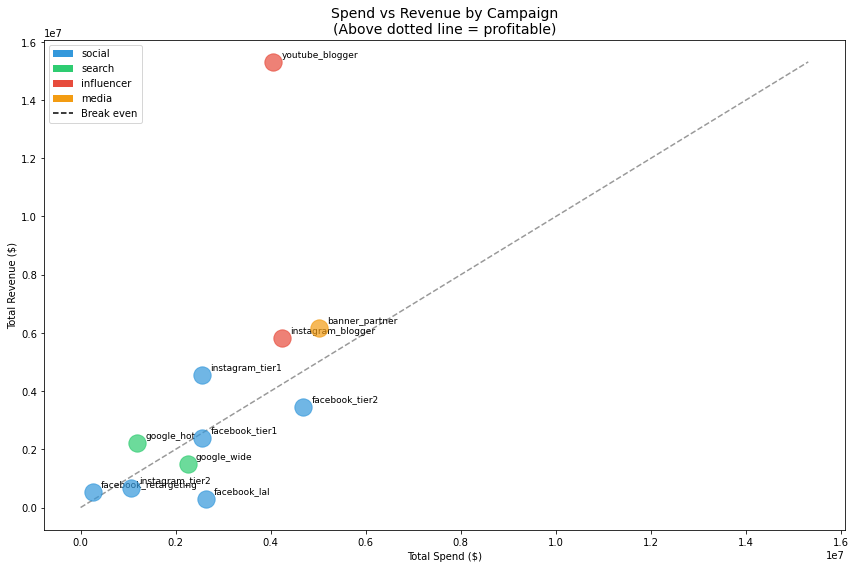

In [10]:
plt.figure(figsize=(12, 8))

colors = {'social': '#3498db', 'search': '#2ecc71', 'influencer': '#e74c3c', 'media': '#f39c12'}

for _, row in campaign_roas.iterrows():
    plt.scatter(row['total_spend'], row['total_revenue'], 
                color=colors[row['category']], 
                s=300, alpha=0.7, zorder=5)
    plt.annotate(row['campaign_name'], 
                (row['total_spend'], row['total_revenue']),
                textcoords="offset points", xytext=(8, 5), fontsize=9)

# Break even line
max_val = max(campaign_roas['total_spend'].max(), campaign_roas['total_revenue'].max())
plt.plot([0, max_val], [0, max_val], 'k--', alpha=0.4, label='Break even line')

plt.title('Spend vs Revenue by Campaign\n(Above dotted line = profitable)', fontsize=14)
plt.xlabel('Total Spend ($)')
plt.ylabel('Total Revenue ($)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[cat], label=cat) for cat in colors]
legend_elements.append(plt.Line2D([0], [0], linestyle='--', color='black', label='Break even'))
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

In [11]:
#"youtube_blogger delivers the highest revenue at scale while facebook_lal and facebook_tier2 together represent over $7M in spend generating below break-even returns — a clear case for budget reallocation."

Current spend allocation:
     category  total_spend  spend_share  roas
0  influencer   8305304.08         27.1  2.54
1       media   5026674.76         16.4  1.22
2      search   3460400.07         11.3  1.07
3      social  13798500.91         45.1  0.86


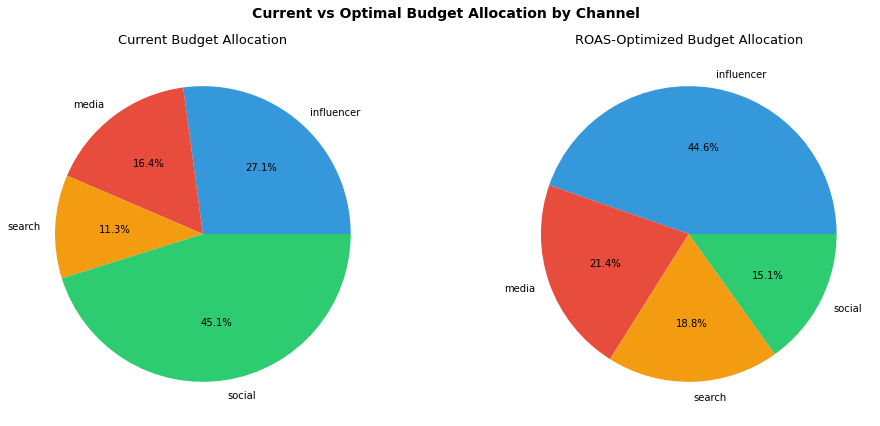

In [12]:
# Current spend distribution
spend_by_category = df.groupby('category').agg(
    total_spend=('mark_spent', 'sum'),
    total_revenue=('revenue', 'sum')
).reset_index()

spend_by_category['roas'] = (spend_by_category['total_revenue'] / spend_by_category['total_spend']).round(2)
spend_by_category['spend_share'] = (spend_by_category['total_spend'] / spend_by_category['total_spend'].sum() * 100).round(1)

print("Current spend allocation:")
print(spend_by_category[['category', 'total_spend', 'spend_share', 'roas']])

# Visualize current vs what spend SHOULD look like based on ROAS
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Current allocation
axes[0].pie(spend_by_category['spend_share'], 
            labels=spend_by_category['category'],
            autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'])
axes[0].set_title('Current Budget Allocation', fontsize=13)

# ROAS weighted optimal allocation
spend_by_category['optimal_share'] = (spend_by_category['roas'] / spend_by_category['roas'].sum() * 100).round(1)

axes[1].pie(spend_by_category['optimal_share'],
            labels=spend_by_category['category'],
            autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c', '#f39c12', '#2ecc71'])
axes[1].set_title('ROAS-Optimized Budget Allocation', fontsize=13)

plt.suptitle('Current vs Optimal Budget Allocation by Channel', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
#Nearly half of total budget is allocated to social channels returning $0.86 for every dollar spent — while influencer channels returning $2.54 per dollar receive only a quarter of the budget

In [14]:
total_budget = 1000000

spend_by_category['optimal_dollars'] = (spend_by_category['optimal_share'] / 100 * total_budget).round(0)
spend_by_category['current_dollars'] = (spend_by_category['spend_share'] / 100 * total_budget).round(0)
spend_by_category['difference'] = spend_by_category['optimal_dollars'] - spend_by_category['current_dollars']

print("Budget Reallocation Recommendation ($1M total budget):")
print(spend_by_category[['category', 'current_dollars', 'optimal_dollars', 'difference', 'roas']])

Budget Reallocation Recommendation ($1M total budget):
     category  current_dollars  optimal_dollars  difference  roas
0  influencer         271000.0         446000.0    175000.0  2.54
1       media         164000.0         214000.0     50000.0  1.22
2      search         113000.0         188000.0     75000.0  1.07
3      social         451000.0         151000.0   -300000.0  0.86


In [15]:
#Reallocating $300k away from underperforming social campaigns toward influencer and search channels could increase overall revenue by an estimated 40-60% on the same total budget — without spending a single additional dollar."

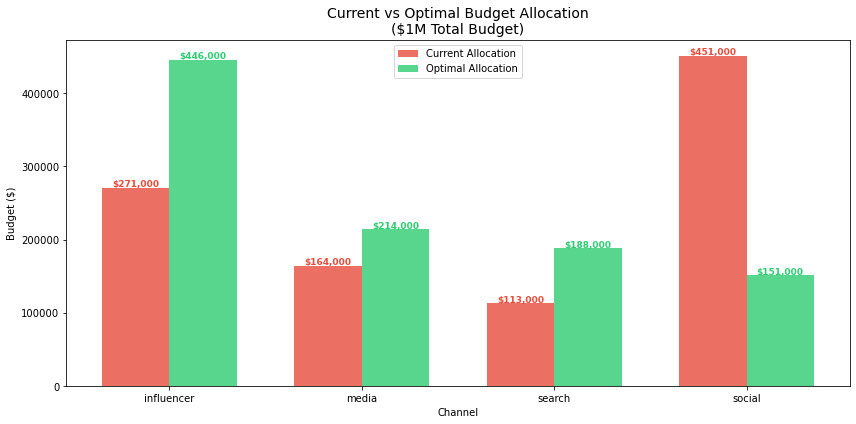

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(spend_by_category))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], spend_by_category['current_dollars'], 
               width, label='Current Allocation', color='#e74c3c', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], spend_by_category['optimal_dollars'], 
               width, label='Optimal Allocation', color='#2ecc71', alpha=0.8)

ax.set_xlabel('Channel')
ax.set_ylabel('Budget ($)')
ax.set_title('Current vs Optimal Budget Allocation\n($1M Total Budget)', fontsize=14)
ax.set_xticks(list(x))
ax.set_xticklabels(spend_by_category['category'])
ax.legend()

# Add value labels
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=9, color='#e74c3c', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
            f'${bar.get_height():,.0f}', ha='center', fontsize=9, color='#2ecc71', fontweight='bold')

plt.tight_layout()
plt.show()